In [ ]:
%pip install geopandas rasterio rasterstats shapely
%pip install pandas
%pip install scikit-learn
%pip install shap
%pip install fasttreeshap

In [2]:
from os import path as op
import pickle
from google.colab import files

import pandas as pd
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

In [3]:
from google.colab import drive
drive.mount('/content/drive/', force_remount=True)

Mounted at /content/drive/


In [4]:
import os

# list the folders and files in your drive
mydrive = '/content/drive/My Drive'
colab = '/content/drive/My Drive/Colab Notebooks/Ground Cover Model'
print(os.listdir(mydrive))

# list the current working directory
print(os.getcwd())

# make a data folder in your Colab Notebook directory if it doesn't exist
data_folder = os.path.join(colab,'data')
os.path.isdir(data_folder)
if (not os.path.isdir(data_folder)):
  os.mkdir(data_folder)
# list the contents
print(os.listdir(colab))

['RF_model (mgf).ipynb', 'Colab Notebooks']
/content
['data']


In [5]:
my_root_dir = "/content/drive/My Drive/Colab Notebooks/Ground Cover Model/data"

In [6]:
training_output = '/content/drive/My Drive/Colab Notebooks/Ground Cover Model/data/geotraining_data.geojson'
training_data = gpd.read_file(training_output)
#print data frame
training_data.shape
training_data.head()

,# N,classCode,LCP_Band,B1,B2,B3,B4,B5,B6,B8A,...,NIR_SWIR_2,SWIR_1_SWIR_2,RS2,GNDVI (F),SAVI (F),BN (F),North,East,Reliability Level,geometry
0,70,1,36,0.103508,0.107830,0.153940,0.222003,0.253280,0.270493,0.350653,...,0.107295,0.157795,-0.120258,-0.181046,0.179904,-0.529623,-6.889678,111.520950,3,POINT (111.52095 -6.88968)
1,69,1,36,0.098214,0.094611,0.138907,0.171313,0.215596,0.279234,0.366715,...,0.209747,0.203435,-0.166086,-0.104461,0.282365,-0.589830,-6.889678,111.520950,3,POINT (111.52095 -6.88968)
2,65,1,36,0.077361,0.124520,0.190246,0.274244,0.285004,0.344430,0.409372,...,0.202520,0.175649,0.005056,-0.180839,0.171248,-0.533539,-6.888956,111.520900,3,POINT (111.52090 -6.88896)
3,61,1,36,0.077475,0.099007,0.154509,0.207376,0.221950,0.319847,0.449017,...,0.324415,0.230346,-0.049649,-0.146088,0.313441,-0.638676,-6.888774,111.520880,3,POINT (111.52088 -6.88877)
4,96,1,37,0.059083,0.065902,0.092936,0.113770,0.131243,0.165071,0.187771,...,0.011517,0.053818,-0.234555,-0.100790,0.138485,-0.480418,-7.054047,107.744736,3,POINT (107.74474 -7.05405)


In [7]:
classes = np.unique(training_data.classCode)
classes

array([1, 2, 3, 4, 5, 6, 7, 8, 9])

In [8]:
# create a dictionary to convert class names into integers for modeling
class_names = {1:'Dense Short Vegetation',
               2:'Open Tree Cover',
               3:'Dense Tree Cover',
               4:'Wetland Tree Cover',
               5:'Built Up',
               6:'Water',
               7:'Cropland Cultivation',
               8:'Cropland Growing',
               9:'Cropland Harvest'}

class_dict = dict(zip(classes, range(len(class_names))))
class_dict
lc_classes = dict(zip(class_names.values(), range(len(class_dict))))
lc_classes
keys = ['Dense Short Vegetation', 'Open Tree Cover', 'Dense Tree Cover', 'Wetland Tree Cover', 'Built Up', 'Water', 'Cropland Cultivation', 'Cropland Growing', 'Cropland Harvest']
values = [1, 2, 3, 4, 5, 6, 7, 8, 9]
lc_classes.update(zip(keys, values))
lc_classes.items()
lc_classes

{'Dense Short Vegetation': 1,
 'Open Tree Cover': 2,
 'Dense Tree Cover': 3,
 'Wetland Tree Cover': 4,
 'Built Up': 5,
 'Water': 6,
 'Cropland Cultivation': 7,
 'Cropland Growing': 8,
 'Cropland Harvest': 9}

In [9]:
y_raw =[]
for i in training_data.classCode: 
  [i for i in lc_classes.values()]
  y_raw.append(i)
print(y_raw)

[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 

In [10]:
X = np.array(training_data)
y = np.array(y_raw)
(X.shape, y.shape)

((103103, 25), (103103,))

In [11]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print (X_test.shape)
print (y_test.shape)

(20621, 25)
(20621,)


In [12]:
arr1inds = X_test[:,23].argsort()
X_test_sorted = X_test[arr1inds[::-1]]
y_test_sorted = y_test[arr1inds[::-1]]

print (X_test_sorted[:,23])
print (y_test_sorted)
X_test_sorted[0:20,]
y_test_sorted[0:20,]

[3 3 3 ... 2 2 2]
[1 5 5 ... 2 1 3]


array([1, 5, 5, 1, 5, 1, 5, 9, 1, 7, 1, 3, 1, 7, 8, 1, 5, 9, 7, 2])

In [13]:
labels, counts = np.unique(y, return_counts=True)
class_weight_dict = dict(zip(labels, 1 / counts))
class_weight_dict

{1: 3.278366062354523e-05,
 2: 5.8668231152830744e-05,
 3: 6.833868653044489e-05,
 4: 0.001075268817204301,
 5: 5.2664840952180324e-05,
 6: 0.0005509641873278236,
 7: 0.00013808340237503452,
 8: 0.00013700506918755994,
 9: 0.0002151462994836489}

**GGCC Model**

In [14]:
clf = RandomForestClassifier(
    n_estimators=390,
    class_weight=class_weight_dict,
    max_depth=17,
    min_samples_split=22,
    max_samples=0.8,
    max_features='log2',
    oob_score=True,
    bootstrap=True,
    n_jobs=-1,
    verbose=1,
    random_state=0)

In [15]:
columns_ = np.r_[X[:,3:21]]
clf.fit(columns_,y)
final_model = clf

[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=-1)]: Done  46 tasks      | elapsed:   20.1s
[Parallel(n_jobs=-1)]: Done 196 tasks      | elapsed:  1.4min
[Parallel(n_jobs=-1)]: Done 390 out of 390 | elapsed:  2.7min finished


In [16]:
data_input = '/content/drive/My Drive/Colab Notebooks/Ground Cover Model/data/predict_tiles.geojson'
java = gpd.read_file(data_input)
#print data frame
java.shape
java.head()

,id,preds,xcoord,ycoord,B1,B2,B3,B4,B5,B6,...,B11,B12,NDVI,NIR_SWIR_2,SWIR_1_2,RS2,GR,SAVI,BN,geometry
0,1,2.0,11708930.0,-733695.4818,0.028441,0.034567,0.057417,0.035795,0.072207,0.238716,...,0.135661,0.050697,0.828068,0.764902,0.455916,-0.172298,0.231973,0.564381,-0.833475,"MULTIPOLYGON (((11713930.000 -728695.482, 1171..."
1,2,1.0,11708930.0,-743695.4818,0.026907,0.035169,0.059218,0.037818,0.074907,0.240213,...,0.134632,0.050775,0.819371,0.764765,0.452287,-0.146251,0.220533,0.560175,-0.830954,"MULTIPOLYGON (((11713930.000 -738695.482, 1171..."
2,3,1.0,11718930.0,-733695.4818,0.028273,0.036396,0.059392,0.039476,0.075535,0.232924,...,0.134602,0.052689,0.806430,0.749746,0.437355,-0.143366,0.201438,0.543447,-0.820173,"MULTIPOLYGON (((11723930.000 -728695.482, 1172..."
3,4,2.0,11718930.0,-753695.4818,0.025127,0.032790,0.057115,0.035614,0.075578,0.238711,...,0.129728,0.047897,0.827624,0.774861,0.460693,-0.147090,0.231871,0.561725,-0.840198,"MULTIPOLYGON (((11723930.000 -748695.482, 1172..."
4,5,1.0,11718930.0,-763695.4818,0.029454,0.035190,0.057402,0.037804,0.073191,0.227222,...,0.121652,0.047278,0.806385,0.763598,0.440264,-0.111354,0.205848,0.530426,-0.818560,"MULTIPOLYGON (((11723930.000 -758695.482, 1172..."


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

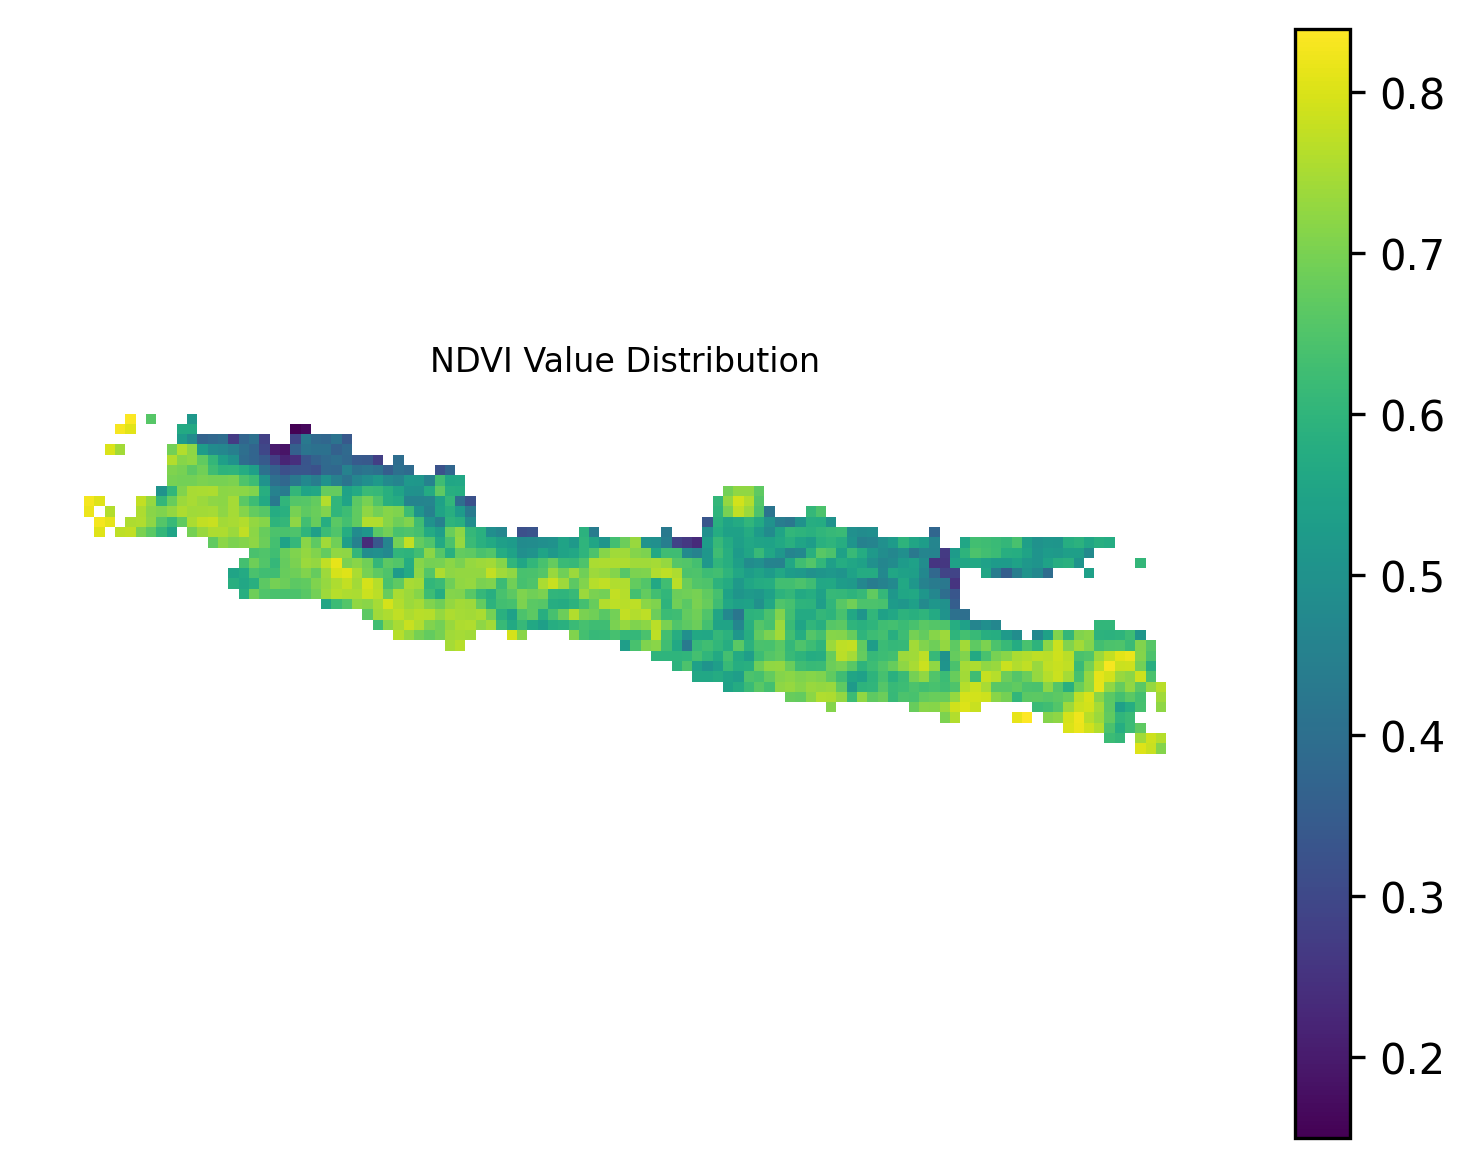

In [76]:
fig, ax = plt.subplots(dpi=300)

java.plot(ax=ax,column='NDVI',legend=True,figsize=(15,8),cmap='viridis')
plt.title("NDVI Value Distribution",fontsize=8)

ax.axis('off')
plt.savefig('fig(Java_NDVI).png')
files.download('fig(Java_NDVI).png')

In [18]:
X_vars = ['B1', 'B2', 'B3', 'B4', 'B5', 'B6', 'B7', 'B8', 'B8A', 'B11', 'B12', 'NDVI', 'NIR_SWIR_2', 'SWIR_1_2', 'RS2', 'GR', 'SAVI', 'BN']
data_all = java[X_vars]
y = java['preds']
coords = java[['xcoord','ycoord']].values
data_all.shape

(1391, 18)

In [19]:
data_all.head()

,B1,B2,B3,B4,B5,B6,B7,B8,B8A,B11,B12,NDVI,NIR_SWIR_2,SWIR_1_2,RS2,GR,SAVI,BN
0,0.028441,0.034567,0.057417,0.035795,0.072207,0.238716,0.319789,0.302708,0.380587,0.135661,0.050697,0.828068,0.764902,0.455916,-0.172298,0.231973,0.564381,-0.833475
1,0.026907,0.035169,0.059218,0.037818,0.074907,0.240213,0.320039,0.301799,0.380921,0.134632,0.050775,0.819371,0.764765,0.452287,-0.146251,0.220533,0.560175,-0.830954
2,0.028273,0.036396,0.059392,0.039476,0.075535,0.232924,0.309793,0.291776,0.368396,0.134602,0.052689,0.806430,0.749746,0.437355,-0.143366,0.201438,0.543447,-0.820173
3,0.025127,0.032790,0.057115,0.035614,0.075578,0.238711,0.317900,0.300706,0.377595,0.129728,0.047897,0.827624,0.774861,0.460693,-0.147090,0.231871,0.561725,-0.840198
4,0.029454,0.035190,0.057402,0.037804,0.073191,0.227222,0.299608,0.285280,0.352702,0.121652,0.047278,0.806385,0.763598,0.440264,-0.111354,0.205848,0.530426,-0.818560


In [20]:
y_pred = final_model.predict(data_all)

/usr/local/lib/python3.9/dist-packages/sklearn/base.py:432: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(
[Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done  46 tasks      | elapsed:    0.0s
[Parallel(n_jobs=2)]: Done 196 tasks      | elapsed:    0.1s
[Parallel(n_jobs=2)]: Done 390 out of 390 | elapsed:    0.2s finished


In [21]:
from sklearn.metrics import mean_squared_error, r2_score

print(np.sqrt(mean_squared_error(y, y_pred)))
print(r2_score(y, y_pred))

2.2487315699336157
-1.262491542503918


In [22]:
import fasttreeshap
shap_explainer = fasttreeshap.TreeExplainer(final_model, algorithm='auto', n_jobs=-1)
shap_values = shap_explainer(data_all)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

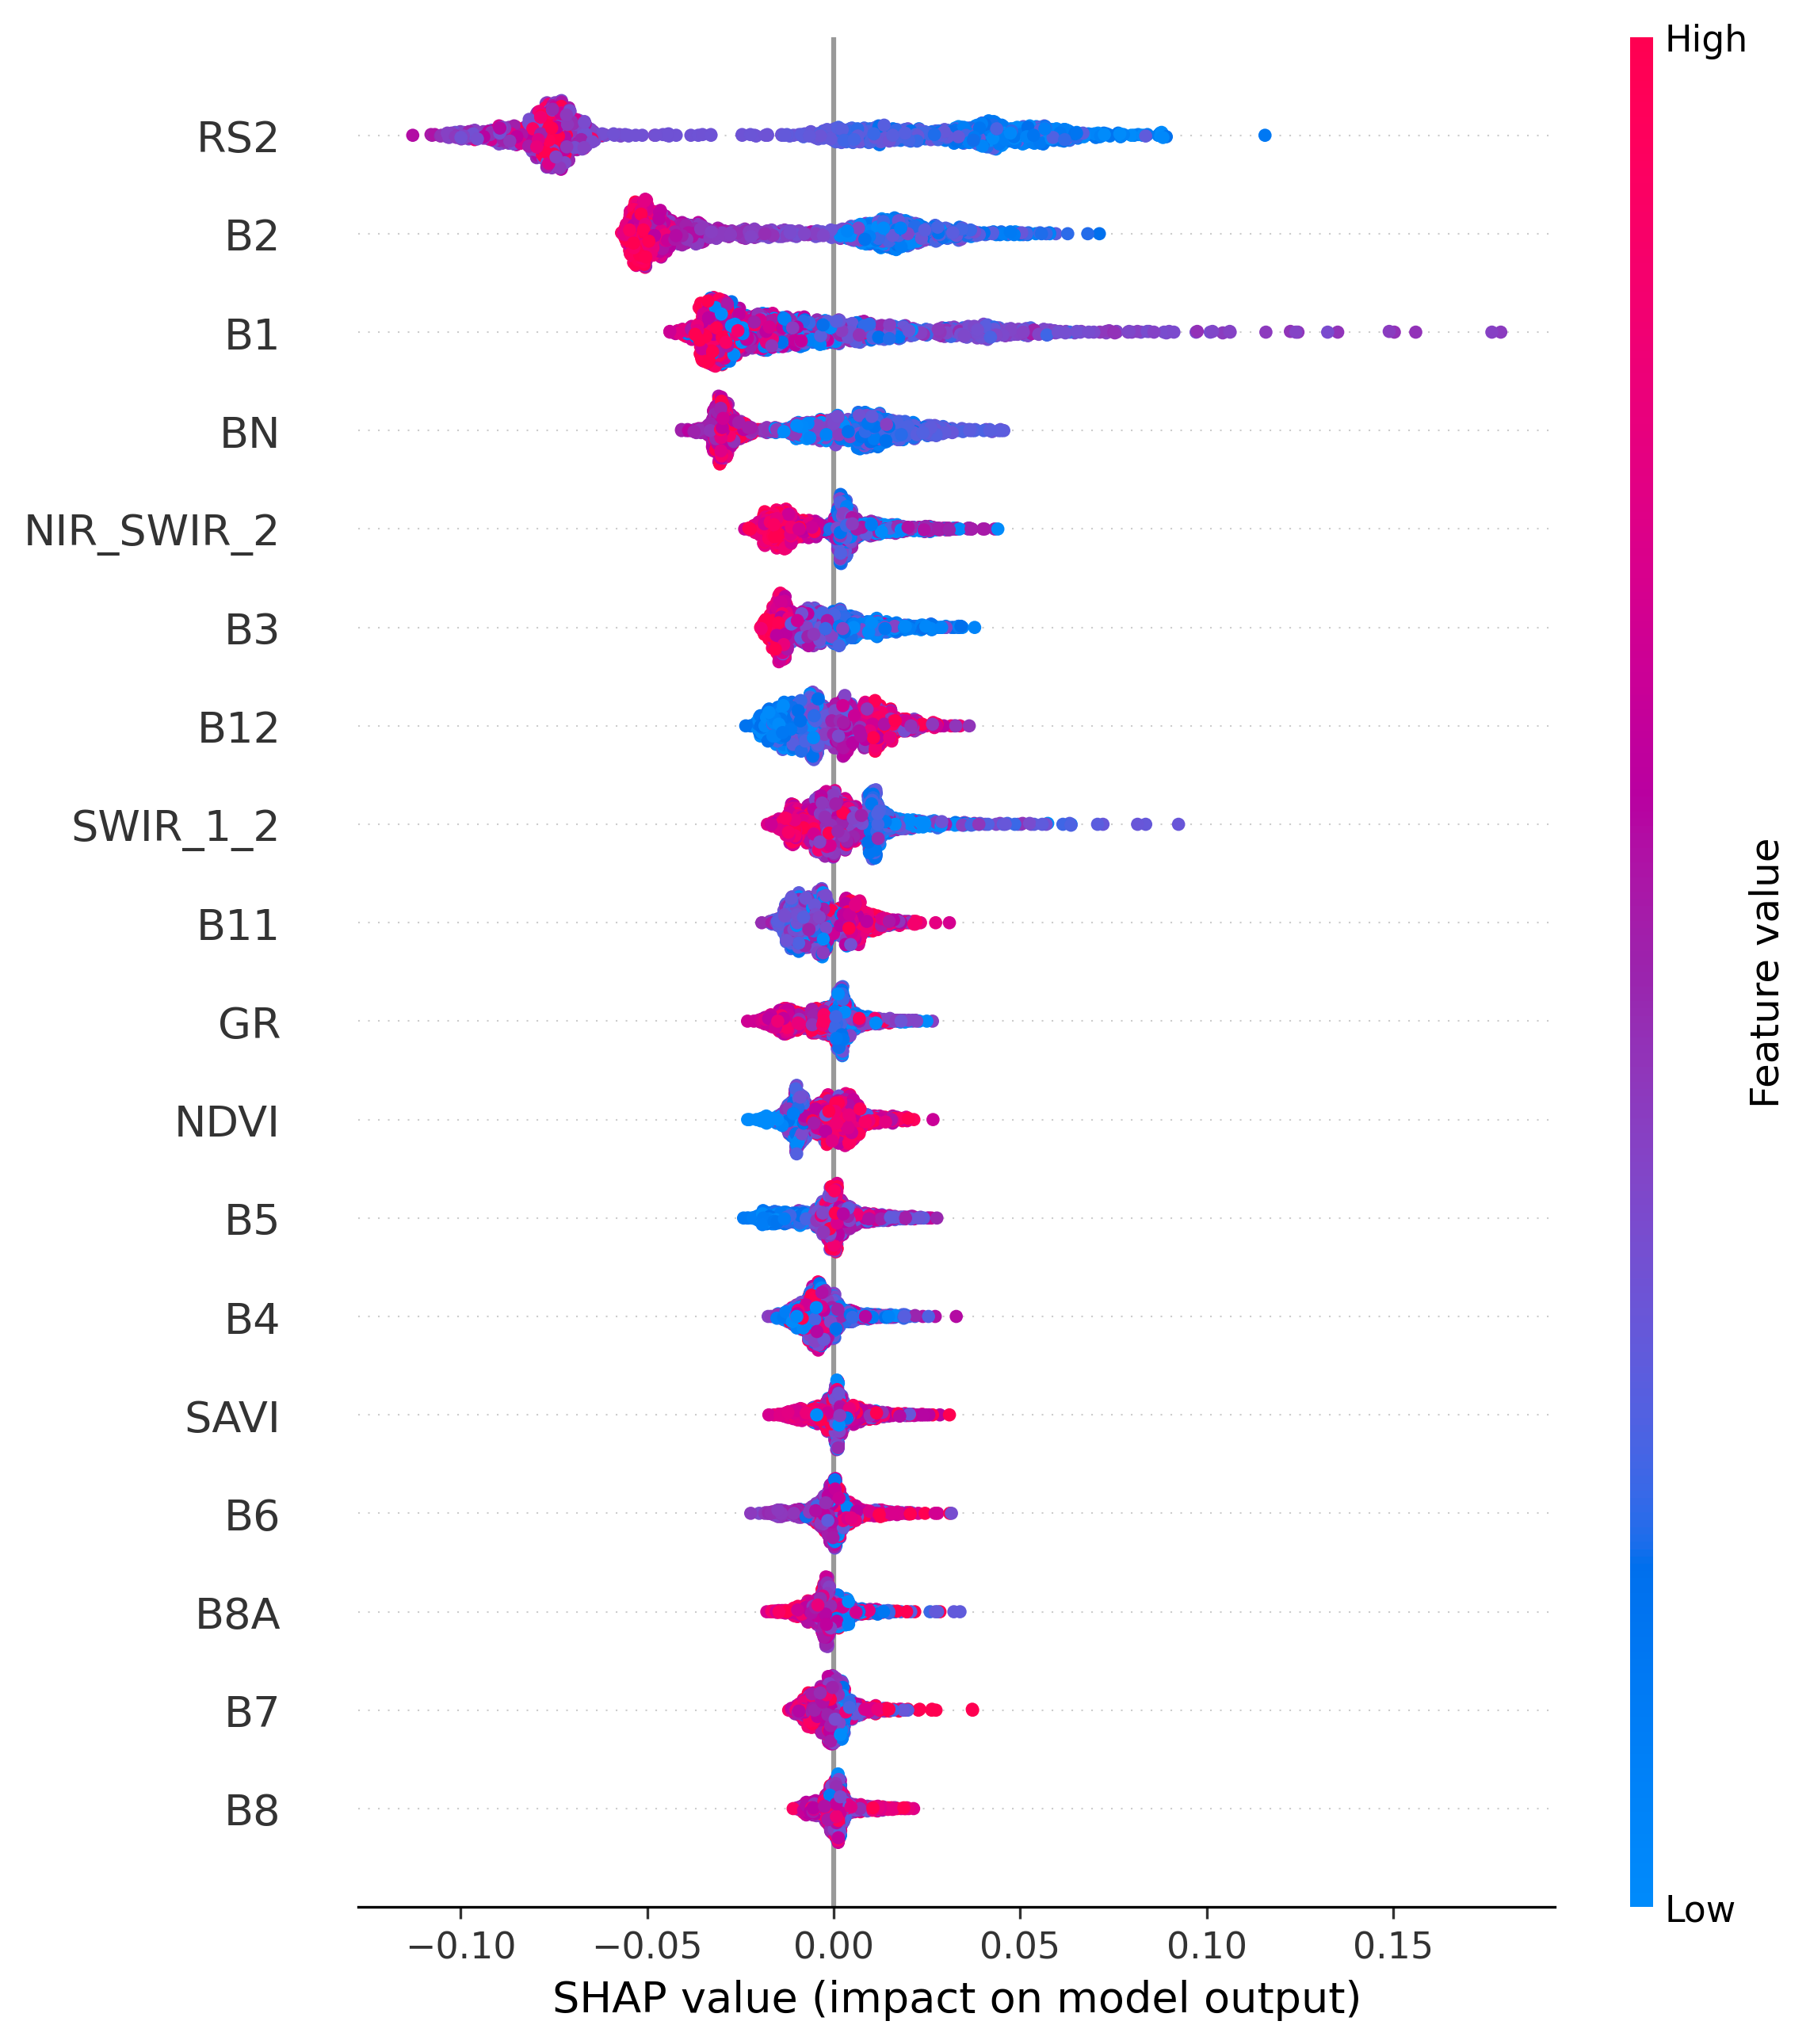

In [75]:
import shap
shap.initjs()
#shap.summary_plot(shap_values.values, data_all)

fig, ax = plt.subplots(figsize=(5, 5),dpi=300)

shap.summary_plot(shap_values[:,:,4], features= data_all, class_inds=[1], show=False)

#shap.summary_plot(shap_values.values[:,:,6], plot_type="bar",
#                  feature_names=data_all.columns)
plt.savefig('fig(shap_globBuilt_SHAP).png')
files.download('fig(shap_globBuilt_SHAP).png')

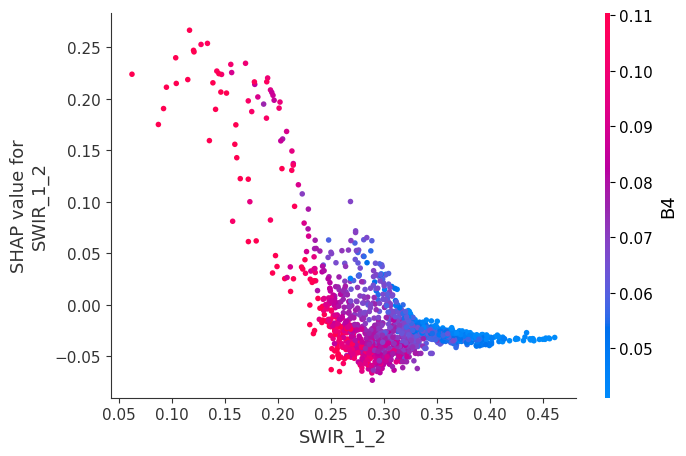

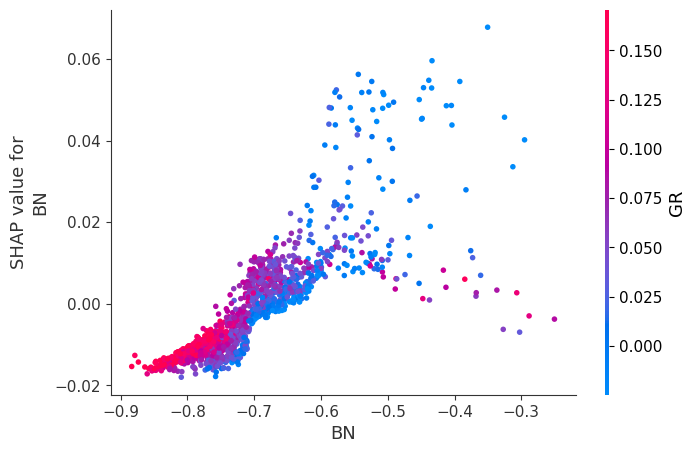

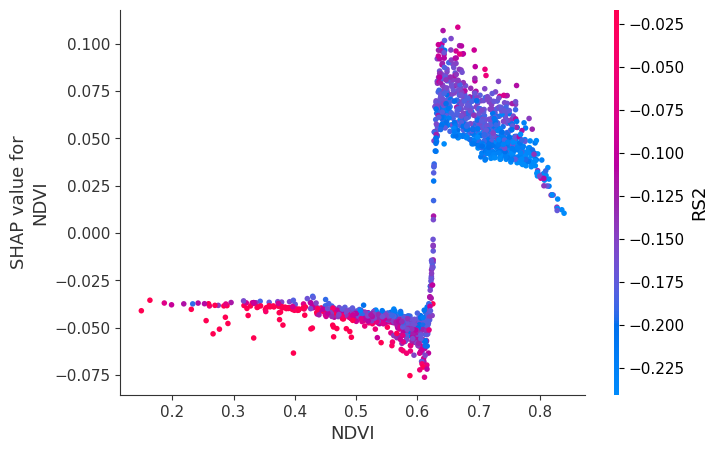

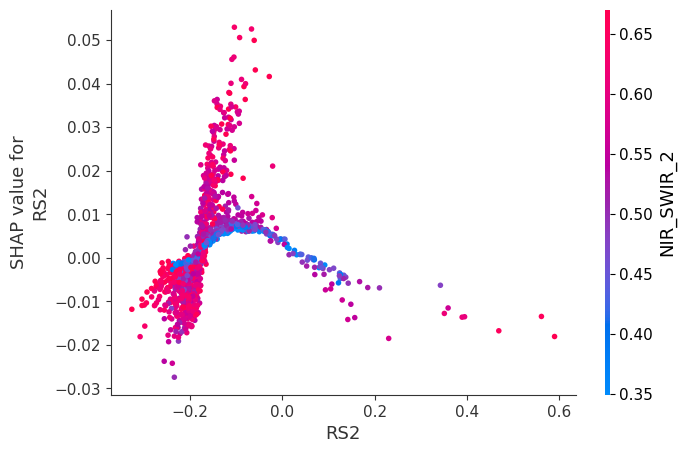

In [31]:
#Built Up (#4)
shap.dependence_plot("SWIR_1_2",
                     shap_values.values[:,:,4],
                     features=data_all,
                     feature_names=data_all.columns
                     )
#Built Up (#4)
shap.dependence_plot("BN",
                     shap_values.values[:,:,4],
                     features=data_all,
                     feature_names=data_all.columns
                     )
#Cropland (#6)
shap.dependence_plot("NDVI",
                     shap_values.values[:,:,6],
                     features=data_all,
                     feature_names=data_all.columns
                     )
#Cropland (#6)
shap.dependence_plot("RS2",
                     shap_values.values[:,:,6],
                     features=data_all,
                     feature_names=data_all.columns
                     )


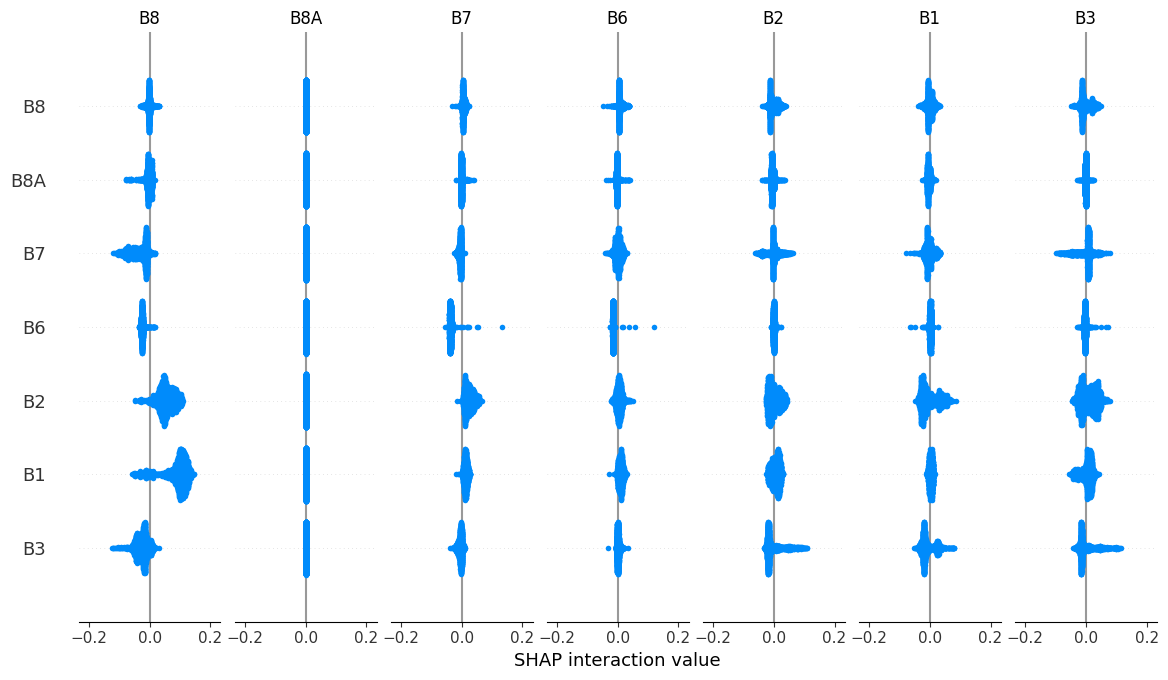

In [32]:
shap.summary_plot(shap_values.values, features=data_all.columns)

This Part Estimates the 95% Confidence Intervals around SHAP values with Residual Resampling Bootstrapping.

1- Randomly resample with replacement.

2- Calculate errors.

3- Compute shap values and save.



Gets the 97.5 percentile and 2.5 percentile from the sampling distribution.

In [ ]:
# compute SHAP interaction values via FastTreeSHAP v1
shap_explainer = fasttreeshap.TreeExplainer(final_model, algorithm = "v1", n_jobs = -1)
shap_interaction_values_v1 = shap_explainer(data_all, interactions = True).values
shap_interaction_values_v1.shape

In [24]:
from tqdm import tqdm
import fasttreeshap

shap_bootstrap_list = []


n = y.shape[0]
err = y - y_pred
    
for i in tqdm(range(100)):
        
    random_sample_index = np.random.choice(np.arange(n), size=n, replace=True)
        
    y_sample = y_pred + err[random_sample_index]
        
    sample_model = clf.fit(data_all, y_sample)
    explainer_shap = fasttreeshap.Explainer(sample_model)
    shap_values = explainer_shap(data_all)

    shap_bootstrap_list.append(shap_values.values)
        
w = np.dstack((shap_bootstrap_list))
w.shape

  0%|          | 0/100 [00:00<?, ?it/s][Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=-1)]: Done  46 tasks      | elapsed:    0.2s
[Parallel(n_jobs=-1)]: Done 196 tasks      | elapsed:    1.0s
[Parallel(n_jobs=-1)]: Done 390 out of 390 | elapsed:    1.9s finished
  1%|          | 1/100 [00:23<38:57, 23.61s/it][Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=-1)]: Done  46 tasks      | elapsed:    0.4s
[Parallel(n_jobs=-1)]: Done 196 tasks      | elapsed:    1.6s
[Parallel(n_jobs=-1)]: Done 390 out of 390 | elapsed:    3.1s finished
  2%|▏         | 2/100 [00:47<38:27, 23.54s/it][Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=-1)]: Done  46 tasks      | elapsed:    0.2s
[Parallel(n_jobs=-1)]: Done 196 tasks      | elapsed:    0.9s
[Parallel(n_jobs=-1)]: Done 390 out of 390 | elapsed:    1.8s finished
  3%|▎         | 3/100 [01:12<39:17, 24

(1391, 18, 1910)

In [25]:
l_shap_global = np.abs(w).mean(axis=1).mean(axis=0) - \
                np.percentile(np.abs(w).mean(axis=1),axis=0, q=2.5)
                
u_shap_global = np.percentile(np.abs(w).mean(axis=1),axis=0, q=97.5) - \
                np.abs(w).mean(axis=1).mean(axis=0)

In [26]:
l_95 = np.percentile(w,axis=1,q=2.5)
u_95 = np.percentile(w,axis=1,q=97.5)

In [27]:
import seaborn as sns

def plot(ax,term=0):
    
    order = np.argsort(data_all.values[:,term])

    ax.fill_between(data_all.values[:,term][order], l_95[:,term][order], 
                     u_95[:,term][order],color='gainsboro',alpha=0.7)
    
    ax.scatter(data_all.values[:,term][order], w.mean(axis=1)[:,term][order],
                s=5,facecolors='none', edgecolors='black', linewidth=0.2)
    
    ax.axhline(0,color='r', linestyle='--',linewidth=0.8) 
    for item in (ax.get_xticklabels() + ax.get_yticklabels()): item.set_fontsize(6)
    ax.set_xlabel(X_vars[term],fontsize=9)
    #ax.set_ylim(-2.5,2.5)
    ax.set_ylabel("SHAP value",fontsize=9)
    plt.tight_layout()

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

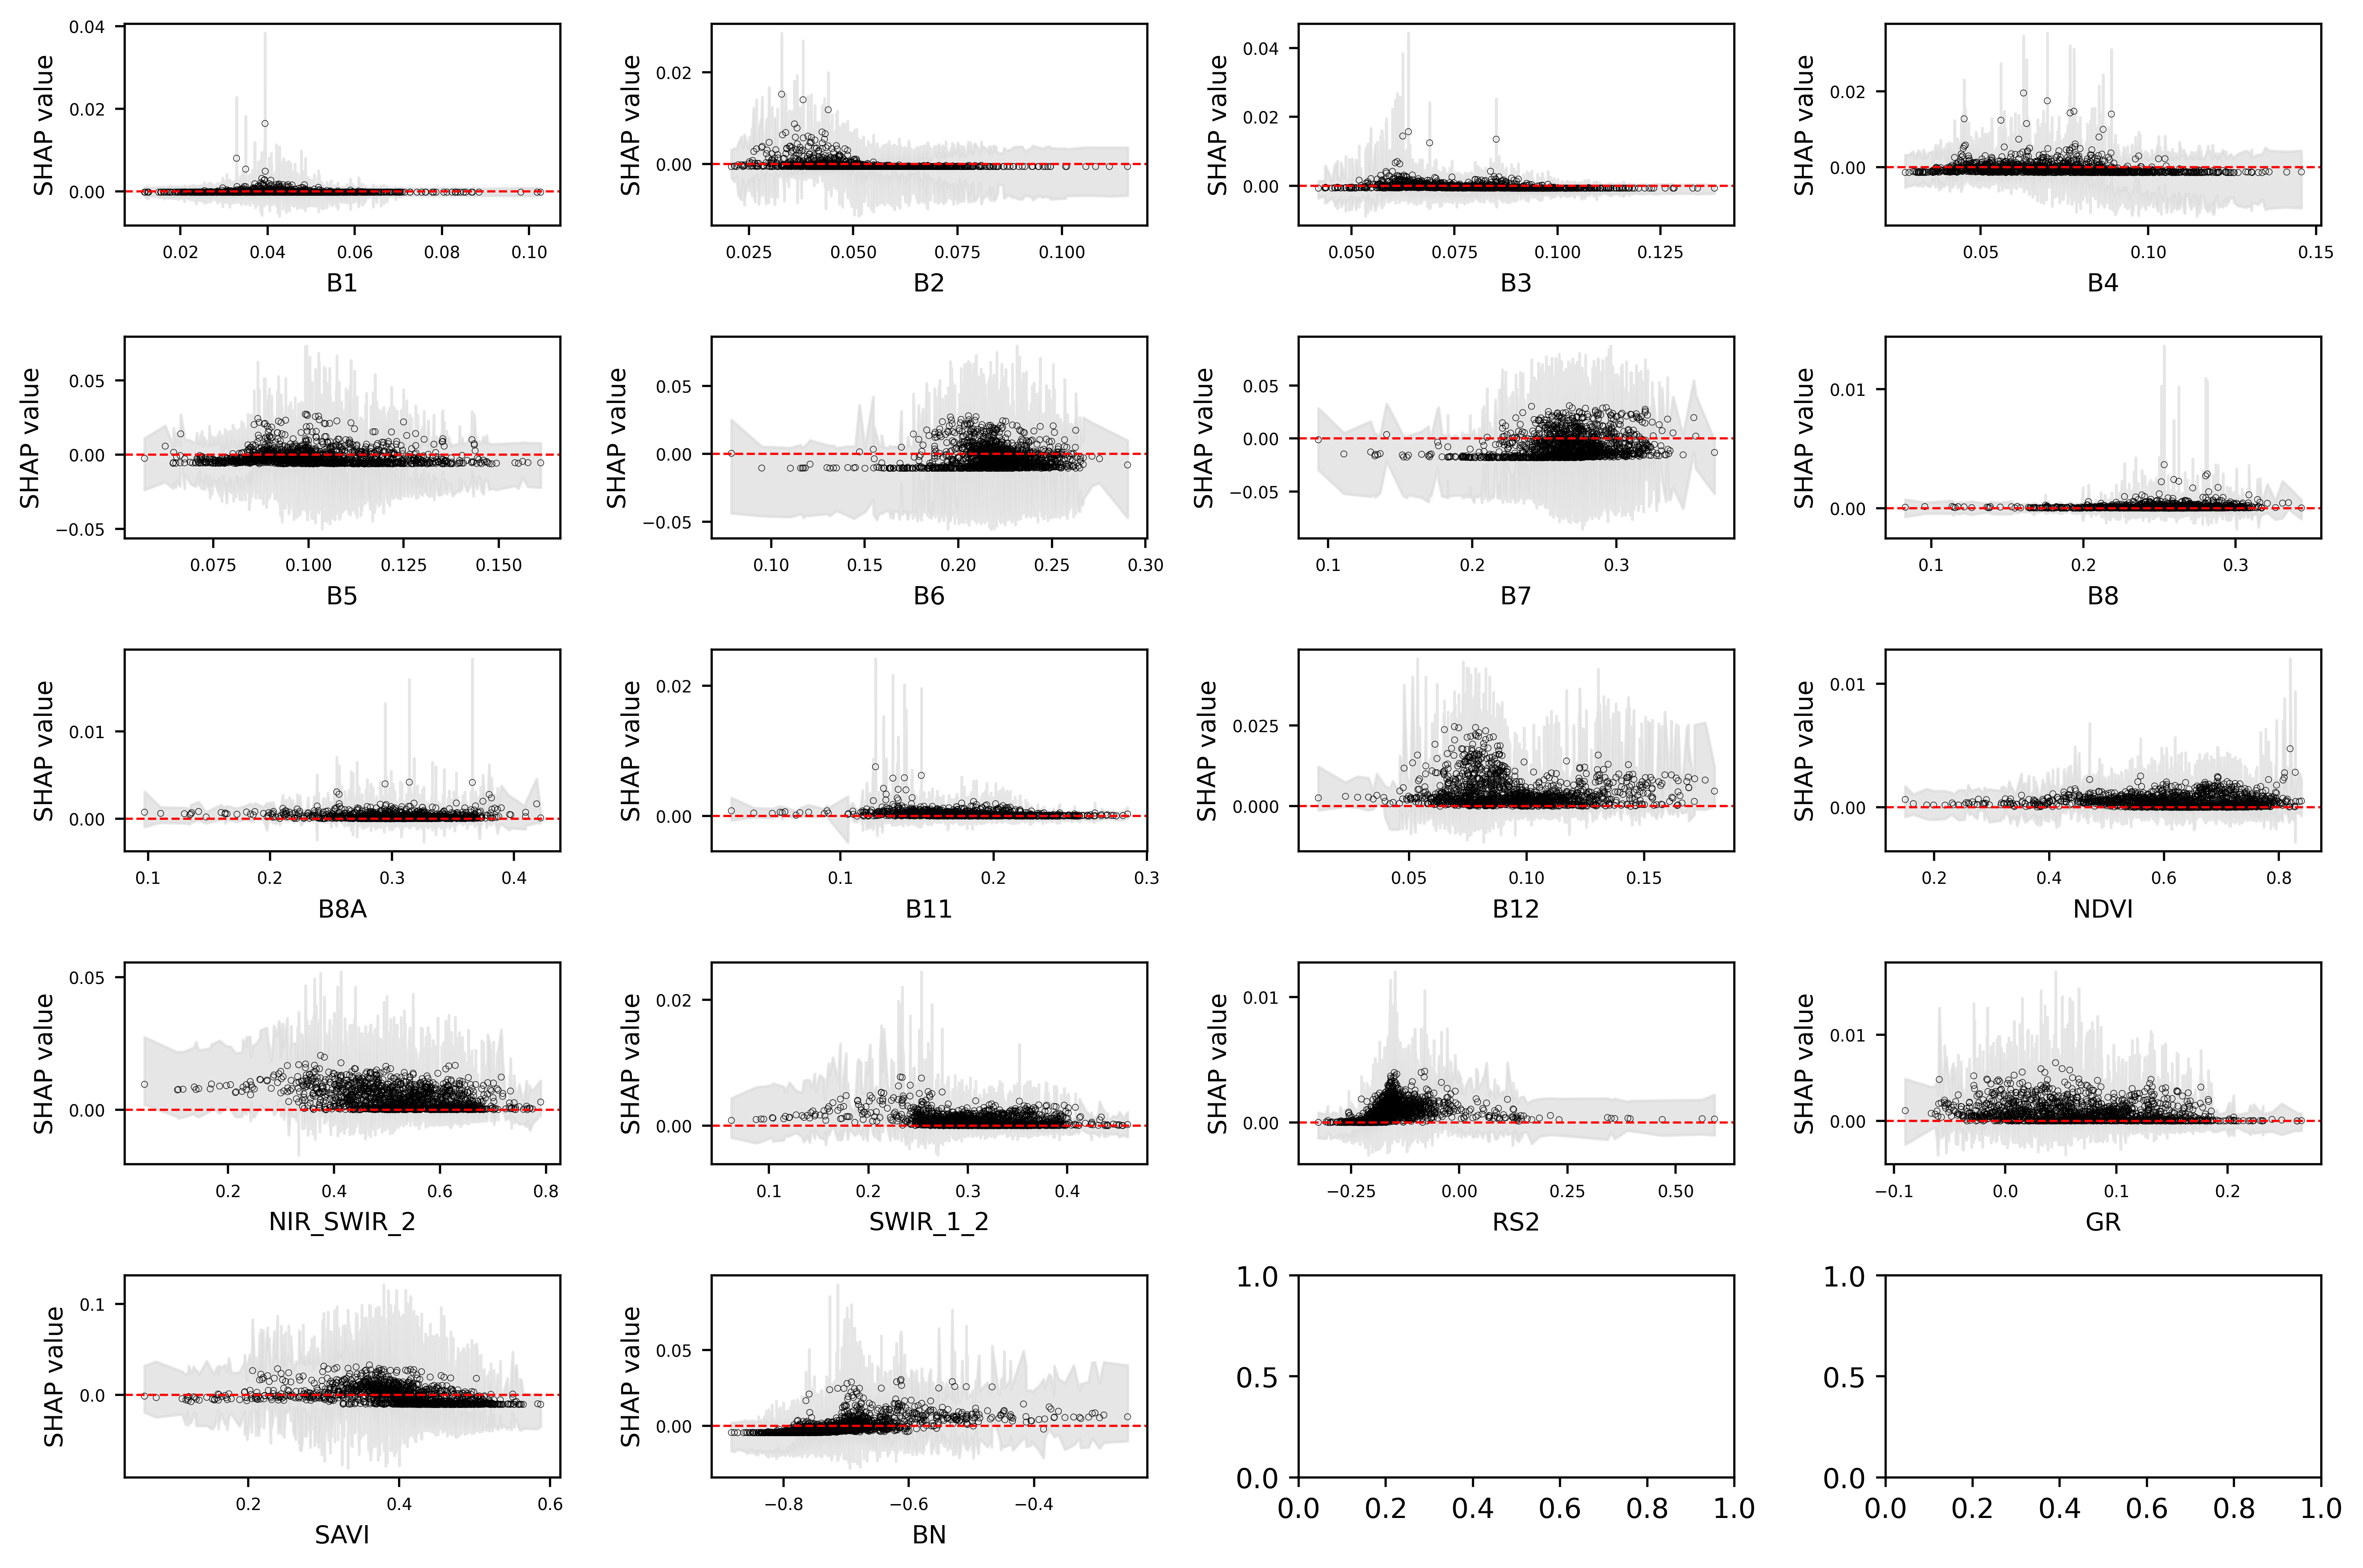

In [29]:
from google.colab import files

fig, ax = plt.subplots(5,4,figsize=(12,8),dpi=500)
ax = ax.ravel()
index = 0
for j in [0, 1, 2, 3, 4, 5, 6, 7, 8,9, 10, 11, 12, 13, 14, 15, 16, 17]:
    plot(ax=ax[index],term=j)
    index += 1
plt.savefig('fig(95_CI).png')
files.download('fig(95_CI).png')

# GeoPlots: Local and Global Shap Values

In [30]:
indata = '/content/drive/My Drive/Colab Notebooks/Ground Cover Model/data/geo_plots.geojson'
geo_plot = gpd.read_file(indata)
#print data frame
geo_plot.shape
geo_plot.head()

,xcoord,ycoord,B1,B2,B3,B4,B5,B6,B7,B8,...,B11,B12,NDVI,NIR_SWIR_2,SWIR_1_2,RS2,GR,SAVI,BN,geometry
0,11708930.0,-733695.4818,0.028441,0.034567,0.057417,0.035795,0.072207,0.238716,0.319789,0.302708,...,0.135661,0.050697,0.828068,0.764902,0.455916,-0.172298,0.231973,0.564381,-0.833475,"MULTIPOLYGON (((11713930.000 -728695.482, 1171..."
1,11708930.0,-743695.4818,0.026907,0.035169,0.059218,0.037818,0.074907,0.240213,0.320039,0.301799,...,0.134632,0.050775,0.819371,0.764765,0.452287,-0.146251,0.220533,0.560175,-0.830954,"MULTIPOLYGON (((11713930.000 -738695.482, 1171..."
2,11718930.0,-733695.4818,0.028273,0.036396,0.059392,0.039476,0.075535,0.232924,0.309793,0.291776,...,0.134602,0.052689,0.806430,0.749746,0.437355,-0.143366,0.201438,0.543447,-0.820173,"MULTIPOLYGON (((11723930.000 -728695.482, 1172..."
3,11718930.0,-753695.4818,0.025127,0.032790,0.057115,0.035614,0.075578,0.238711,0.317900,0.300706,...,0.129728,0.047897,0.827624,0.774861,0.460693,-0.147090,0.231871,0.561725,-0.840198,"MULTIPOLYGON (((11723930.000 -748695.482, 1172..."
4,11718930.0,-763695.4818,0.029454,0.035190,0.057402,0.037804,0.073191,0.227222,0.299608,0.285280,...,0.121652,0.047278,0.806385,0.763598,0.440264,-0.111354,0.205848,0.530426,-0.818560,"MULTIPOLYGON (((11723930.000 -758695.482, 1172..."


In [70]:
# Local GeoPlots for Built Up(#4) and Cropland (#6) classes.
import shap
from google.colab import files

fig, ax = plt.subplots(6,3,figsize=(25,25), dpi=500)

for j in range(len(X_vars)):
    ax = ax.ravel()
    geo_plot.plot(ax=ax[j], column = shap_values.values[:,j,4], legend=True,
              cmap='Blues')
    ax[j].axis('off')
    ax[j].set_title(X_vars[j],fontsize=14)

plt.tight_layout()
plt.savefig('fig(built_Up).png')
files.download('fig(built_Up).png')
#vmin=-0.01,vmax=0.06,

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [67]:
# Global Shap Values in local feature disturbances.
from google.colab import files

fig, ax = plt.subplots(6,3,figsize=(25,25),dpi=500)
for j in range(len(X_vars)):
    ax = ax.ravel()
    
    geo_plot.plot(ax=ax[j],column = shap_values.data[:,j],legend=True, cmap='YlOrBr')
    
    ax[j].set_title(X_vars[j],fontsize=14)
    ax[j].axis('off')

plt.tight_layout()

plt.savefig('fig(global)_feat.png')
files.download('fig(global)_feat.png')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>